# 1η Εργασία

Μπαρμπαγιάννος Βασίλειος

ΑΕΜ: 10685

Τμήμα Ηλεκτρολόγων Μηχανικών και Μηχανικών Υπολογιστών


# Εκφώνηση

Να γραφεί πρόγραμμα σε οποιαδήποτε γλώσσα προγραμματισμού το οποίο να υλοποιεί ένα
νευρωνικό δίκτυο εμπρόσθιας τροφοδότησης (feedforward NN) (το δίκτυο μπορεί να είναι πλήρως
συνδεδεμένο (MLP) ή συνελικτικό (CNN) ή συνδυασμός) που θα εκπαιδεύεται με τον αλγόριθμο
back-propagation. Το ΝΝ αυτό θα εκπαιδευτεί για να επιλύει οποιοδήποτε πρόβλημα
κατηγοριοποίησης πολλών κλάσεων ΕΚΤΟΣ MNIST με επιβλεπόμενη μάθηση ή αυτό-επιβλεπόμενη
μάθηση.

Όπου δεν υπάρχει σύνολο
ελέγχου χωρίζεται η βάση τυχαία σε σύνολο εκπαίδευσης (60%) και ελέγχου (40%) ή ακολουθείται
τεχνική cross-validation.

**Εξαγωγή Χαρακτηριστικών**

Χρησιμοποιείται ολόκληρη η είσοδος ή επιλέγονται κατάλληλα χαρακτηριστικά για το
διαχωρισμό των δειγμάτων ( π.χ. φωτεινότητες σε κατάλληλες θέσεις, μέση φωτεινότητα γραμμών
στηλών κλπ ) ή μειώνεται η διάσταση των δεδομένων χρησιμοποιώντας PCA.  

**Έκθεση αποτελεσμάτων**

Θα πρέπει να γραφεί έκθεση στην οποία να περιγράφονται: ο αλγόριθμος, να δίνονται
χαρακτηριστικά παραδείγματα ορθής και εσφαλμένης κατηγοριοποίησης καθώς και ποσοστά
επιτυχίας στα στάδια της εκπαίδευσης (training) και του ελέγχου (testing), χρόνος εκπαίδευσης και
ποσοστά επιτυχίας για διαφορετικούς αριθμούς νευρώνων στο κρυφό επίπεδο, διαφορετικές τιμές των
παραμέτρων εκπαίδευσης. Να συγκριθεί η απόδοση του νευρωνικού σε σχέση με την
κατηγοριοποίηση πλησιέστερου γείτονα (Nearest Neighbor) και πλησιέστερου κέντρου κλάσης
(Nearest Class Centroid) της ενδιάμεσης εργασίας. Να σχολιασθούν τα αποτελέσματα και ο κώδικας.

# 1 Κατεβάζω το dataset και εισάγω τις βιβλιοθήκες που θα χρειαστώ.


In [23]:
# Κατεβάζω το CIFAR-100 dataset.
!wget -q https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz -O cifar-100-python.tar.gz
# Αποσυμπιέζω το αρχείο.
!tar -xvzf cifar-100-python.tar.gz

# Βιβλιοθήκες που θα χρειαστώ.
import os, time, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as T
import torchvision.models as models

# sklearn.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix

# Έλεγχος αν χρησιμοποιώ GPU (γρηγορότερη εκπαίδευση).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    !nvidia-smi


cifar-100-python/
cifar-100-python/file.txt~
cifar-100-python/train
cifar-100-python/test
cifar-100-python/meta
Device: cuda
Sun Nov 23 16:50:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             30W /   70W |     548MiB /  15360MiB |      0%      Default |
|              

# 2 Unpickle των δεδομένων.


In [24]:
# Φάκελος στον οποίο βρίσκεται το CIFAR-100 dataset.
DATA_DIR = "cifar-100-python"

# Unpickle των δεδομένων.
def unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

# Φορτώνω τα train και test datasets.
train_dict = unpickle(os.path.join(DATA_DIR, "train"))
test_dict = unpickle(os.path.join(DATA_DIR, "test"))
meta_dict = unpickle(os.path.join(DATA_DIR, "meta"))

# Αποθήκευση των εικόνων και των ετικετών σε numpy arrays (για ταχύτητα).
x_train = train_dict[b'data'] # διάνυσμα 50.000x3072.
y_train = np.array(train_dict[b'fine_labels'], dtype=np.int64) # ετικέτες από 0 έως 99 (100 κλάσεις).
x_test = test_dict[b'data'] # διάνυσμα 10.000x3072.
y_test = np.array(test_dict[b'fine_labels'], dtype=np.int64)

# Λίστα με τα ονόματα των κλάσεων.
label_names = [n.decode('utf-8') for n in meta_dict[b'fine_label_names']]

print("Loaded CIFAR-100: x_train", x_train.shape, "x_test", x_test.shape, "classes", len(label_names))

# Συνάρτηση που μετατρέπει τις εικόνες από flat διανύσματα 1x3072 σε εικόνα Height, Width, Channel (32x32x3).
def flat_to_img_uint8(row):
    r = row[0:1024].reshape(32,32) # red.
    g = row[1024:2048].reshape(32,32) # green.
    b = row[2048:3072].reshape(32,32) # blue.
    img = np.dstack([r,g,b]).astype(np.uint8)
    return img


Loaded CIFAR-100: x_train (50000, 3072) x_test (10000, 3072) classes 100


# 3 Transforms, Dataset wrapper & DataLoaders (με augmentation).


In [25]:
# Απαραίτητο βιβλιοθήκη για μετατροπή εικόνας από numpy array σε PIL image.
# PIL: Python Image Libray. Για επεξεργασία εικόνας.
from torchvision.transforms import ToPILImage

# Μέση τιμή και τυπική απόκλιση. Θα χρησιμοποιηθεί στην κανονικοποίηση των δεδομένων.
CIFAR_MEAN = [0.5071, 0.4867, 0.4408]
CIFAR_STD  = [0.2675, 0.2565, 0.2761]

# Transforms για train και test.
# Στο train κάνω και augmentation.
train_transform = T.Compose([
    ToPILImage(), # από numpy array σε PIL image.
    T.RandomCrop(32, padding=4), # τυχαίο crop 32x32 με padding=4. Είναι το data augmentation (επαύξηση δεδομένων).
    T.RandomHorizontalFlip(), # τυχαίο ορίζοντιο flip. Επίσης data augmentation.
    T.ToTensor(), # μετατροπή σε tensor (ελκυστής στα ελληνικά!).
    T.Normalize(CIFAR_MEAN, CIFAR_STD), # κανονικοποίηση με τις μέση τιμή και τυπική απόκλιση από πριν.
])
# Στο test κάνω μόνον κανονικοποίηση.
test_transform = T.Compose([
    ToPILImage(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD), # μόνο κανονικοποίηση.
])
# NOTE: Το data augmentation βοηθάει για να μην γίνει overfitting.
# Επίσης βοηθάει να γίνει το μοντέλο πιο εύρωστο και ανθεκτικό σε θόρυβο κτλ.
# Επίσης αυξάνει τον όγκο και την ποικιλία των δεδομένων εκπαίδευσης,
# αφού τροποποιεί-"πειράζει" τα ήδη υπάρχοντα δείγματα. Δεν χρειάζεται να έχω παραπάνω δείγματα.
# Πλεονεκτήματα: αυξάνει το generalization, μειώνει το overfitting.
# Αν προσθέσεις θόρυβο στην εικόνα, τότε το μοντέλο γίνεται ανθεκτικό στο θόρυβο,
# αφού μαθαίνει θορυβώδεις εικόνες.

# Dataset wrapper (όπως προηγουμένως).
class CIFAR100Raw(Dataset):
    def __init__(self, X_flat, y, transform=None):
        self.X = X_flat
        self.y = y
        self.transform = transform
    def __len__(self):
        return len(self.y) # επιστρέφει πλήθος εικόνων.
    def __getitem__(self, idx):
        img = flat_to_img_uint8(self.X[idx]) # από flat σε Height,Width,Channel.
        if self.transform:
            img = self.transform(img) # εφαρμόζω transoform.
        else:
            img = T.ToTensor()(img) # μετατροπή σε tensor.
        return img, int(self.y[idx]) # επιστρέφει image και label.

# Δημιουργία train και test datasets.
full_train = CIFAR100Raw(x_train, y_train, transform=train_transform) # όλο το train set με augmentation.
full_test  = CIFAR100Raw(x_test,  y_test,  transform=test_transform) # όλο το test set χωρίς augmentation.

# Το train set το χωρίζουμε σε train set (το 80% του αρχικού test set)
# και validation set (το υπόλοιπο 20% του αρχικού test set).
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Dataloaders: φτιάχνουν batches και ανακατεύουν τα δεδομένα (shuffling) για καλύτερη εκπαίδευση.
# Εδώ έχω τις παραμέτρους. Τις αλλάζω κατά το δοκούν.
# Σημαντική παράμετρος: batch size.
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(full_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("DataLoaders ready. Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(full_test))


DataLoaders ready. Train/Val/Test sizes: 40000 10000 10000


# 4 Φόρτωση pretrained μοντέλου ResNet-18 & προσαρμογή για CIFAR-100.


In [26]:
# Φορτώνω το προεκπαιδευμένο μοντέλο ResNet-18.
# Το μοντέλο έχει ήδη μάθει να αναγνωρίζει γενικά χαρακτηριστικά εικόνων από το ImageNet.
# Συνέπεια: μείωση του χρόνου εκπαίδευσης.

# Το προσαρμόζω προφανώς για το CIFAR-100 dataset.

# Τις παραμέτρους του ResNet που ΔΕΝ ανήκουν στο τελικό layer τις παγώνω
# ώστε να μην ενημερωθούν κατά το backpropagation.

# Φόρτωση pretrained ResNet-18 (σύγχρονη σύνταξη torchvision).
try:
    # torchvision >= 0.13 style.
    weights = models.ResNet18_Weights.DEFAULT
    backbone = models.resnet18(weights=weights)
except Exception:
    # fallback σε παλαιότερη σύνταξη.
    backbone = models.resnet18(pretrained=True)

# Αντικατάσταση final layer.
num_features = backbone.fc.in_features
backbone.fc = nn.Linear(num_features, 100) # Σημείωση: το CIFAR-100 έχει 100 κλάσεις.

# Παγώνω όλες τις παραμέτρους εκτός του τελικού layer. Το κάνω για επιτάχυνση της εκπαίδευσης.
for name, param in backbone.named_parameters():
    if "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Μεταφορά σε συσκευή.
backbone = backbone.to(device)
print("Το μοντέλο ResNet-18 φορτώθηκε. Εκπαιδεύσιμες παράμετροι (μόνο fully connected - fc):")
for name, p in backbone.named_parameters():
    if p.requires_grad:
        print(" ", name)


Το μοντέλο ResNet-18 φορτώθηκε: εκπαιδεύσιμες παράμετροι (μόνο fully connected - fc):
  fc.weight
  fc.bias


# 5 Loss, optimizer (μόνο fc params), mixed precision flag.


In [32]:
# Partial fine tuning: ξεπαγώνω τα layer 3, layer 4 και το τελικό layer.

import torch
import torch.nn as nn

# Αρχικά παγώνω όλες τις παραμέτρους για να αρχίσω από σταθερή κατάσταση.
for param in backbone.parameters():
    param.requires_grad = False

# Ξεπαγώνουμε το final fc.
for param in backbone.fc.parameters():
    param.requires_grad = True

# Ξεπαγώνω τα layer 3 και 4.
for param in backbone.layer4.parameters():
    param.requires_grad = True
for param in backbone.layer3.parameters():
    param.requires_grad = True

# Κρατάω τα Batch Normalization Layers σε evaluation mode και όχι σε training mode.
def set_bn_eval(m):
    if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        m.eval()

backbone.apply(set_bn_eval) # εφαρμόζουμε eval σε όλα τα BN modules.

# Συνάρτηση σφάλματος: cross entropy.
criterion = nn.CrossEntropyLoss()

# Συνάρτηση που μετρά τις εκπαιδεύσιμες παραμέτρους.
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable params after unfreeze (layer3 + layer4 + fc):", count_trainable_params(backbone))

# Ρυθμίσεις optimizer: ξεχωριστά LR groups για head και backbone.
# Συστάσεις LR:
# - lr_fc = 1e-3 (το fc layer ξεκινάει τυχαία, μπορεί να απαιτεί μεγαλύτερο lr)
# - lr_backbone = 1e-4 (μικρότερο lr για τα ξεπαγωμένα residual blocks)
# weight_decay = 5e-4 είναι συνήθης τιμή για regularization.

lr_fc = 5e-4
lr_backbone = 5e-5
weight_decay = 5e-4

# Δημιουργία parameter groups (προσθέτουμε layer3+layer4 ως backbone group).
param_groups = [
    {'params': backbone.fc.parameters(), 'lr': lr_fc},
    {'params': backbone.layer4.parameters(), 'lr': lr_backbone},
    {'params': backbone.layer3.parameters(), 'lr': lr_backbone},
]

# Αν θελήσω να εκτελέσω fine tuning σε περισσότερα layers,
# θα τα προσθέσω εδώ με ακόμη μικρότερο learning rate.

# Optimizer: ο αλγόριθμος ενημέρωσης βαρών.
# Επιλογές:
# - SGD: σταθερό learning rate, δεν το προσαρμόζει αυτόματα.
# - Adam: προσαρμόζει το learning rate ξεχωριστά για κάθε weight.
optimizer = torch.optim.Adam(param_groups, weight_decay=weight_decay)

# Scheduler: αλλάζει το learning rate κατά τη διάρκεια της εκπαίδευσης.
# StepLR, μειώνει το lr κατά factor gamma κάθε step_size εποχές.
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=20, gamma=0.1) # π.χ. μετά από 20 epochs το lr θα μειωθεί κατά 0.1.

# Mixed precision (AMP).
use_amp = True
scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == "cuda" else None

print("Partial unfreeze ready: layer3 + layer4 + fc trainable.")
print("Optimizer groups set. lr_fc =", lr_fc, ", lr_backbone =", lr_backbone)
print("AMP enabled:", bool(scaler))


Trainable params after unfreeze (layer3 + layer4 + fc): 10544740
Partial unfreeze ready: layer3 + layer4 + fc trainable.
Optimizer groups set. lr_fc = 0.0005 , lr_backbone = 5e-05
AMP enabled: True


/tmp/ipython-input-2520982501.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == "cuda" else None


# 6 Training loop (μία εποχή) + evaluate (έτοιμα helper).


In [28]:
# Ενημερωμένη train_one_epoch που κρατάει τα BN των frozen modules σε eval()
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """
    Training για 1 epoch.
    Σημείωση: μετά το model.train() κάνουμε override των BatchNorm modules
    που έχουν παγωμένες παραμέτρους (requires_grad==False) και τα βάζουμε σε eval().
    Αυτό αποτρέπει την ανεπιθύμητη ενημέρωση των running mean/var στα frozen layers.
    """
    model.train()  # γενική κατάσταση training για το μοντέλο

    # --- Βήμα: set BN eval για frozen BN modules ---
    # Για κάθε BatchNorm module, αν όλες οι παράμετροί του έχουν requires_grad==False,
    # το βάζουμε σε eval() ώστε να μην αλλάξει running_mean/var.
    for m in model.modules():
        if isinstance(m, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d, torch.nn.BatchNorm3d)):
            params = list(m.parameters())
            # αν το BN module δεν έχει trainable params -> το κρατάμε σε eval
            if len(params) == 0 or all((not p.requires_grad) for p in params):
                m.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    t0 = time.perf_counter()

    # Βασικός loop (ίδιος με πριν, με autocast('cuda') για συμβατότητα)
    for imgs, targets in loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()

        if scaler is not None:
            # χρήση σύγχρονης συντακτικής μορφής autocast
            if device.type == "cuda":
                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(imgs)
                    loss = criterion(outputs, targets)
            else:
                # σε CPU απλά κανονικά
                outputs = model(imgs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        running_loss += float(loss.item()) * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += preds.eq(targets).sum().item()
        total += targets.size(0)

    epoch_time = time.perf_counter() - t0
    return running_loss / total, correct / total, epoch_time


# 7 Πλήρης training loop με checkpoints, scheduler, και συλλογή ιστορικού.


In [ ]:
EPOCHS = 50 # συνολικός αριθμός εποχών εκπαίδευσης.
CHECKPOINT_EVERY = 5 # αποθήκευση του καλύτερου accuracy κάθε 5 εποχές.
SAVE_DIR = "/content/checkpoints_resnet18" # φάκελος αποθήκευσης.
os.makedirs(SAVE_DIR, exist_ok=True) # δημιουργεί τον φάκελο αν δεν υπάρχει.

# Κρατάω το ιστορικό.
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'train_time': []}
best_val_acc = 0.0 # εδώ κρατάω το καλύτερο accuracy.
best_ckpt = None # εδώ κρατάω το καλύτερο checkpoint path.

print("Starting training loop...")
t_start_total = time.perf_counter() # Ξεκινώ το χρονόμετρο για να μετρήσω τον συνολικό χρόνο εκπαίδευσης,
                                    # και όχι μόνο κάθε εποχής.

for epoch in range(1, EPOCHS + 1):
    # Καλώ τη συνάρτηση train_one_epoch από πριν.
    # Εκπαίδευση μίας εποχής.
    train_loss, train_acc, train_time = train_one_epoch(
        backbone, train_loader, optimizer, criterion, device, scaler=scaler
    )

    # Αξιολόγηση στο validation set.
    val_loss, val_acc, val_time, _, _ = evaluate(backbone, val_loader, criterion, device)

    # Ενημέρωση scheduler μετά την εποχή.
    try:
        scheduler.step()
    except Exception:
        # αν δεν υπάρχει scheduler, αγνοούμε.
        pass

    # Αποθήκευση ιστορικών.
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['train_time'].append(train_time)

    # Εκτύπωση αναφοράς για την τρέχουσα εποχή.
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | times (train,val) = {train_time:.2f}s,{val_time:.2f}s")

    # Αποθήκευση καλύτερου checkpoint.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_ckpt = os.path.join(SAVE_DIR, f"best_resnet18_epoch{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': backbone.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if 'scheduler' in locals() else None,
            'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
            'val_acc': val_acc,
            'history': history
        }, best_ckpt)
        print(f"  -> New best val_acc: {best_val_acc:.4f}. Saved checkpoint: {best_ckpt}")

    # Περιοδική αποθήκευση.
    if epoch % CHECKPOINT_EVERY == 0:
        ckpt_path = os.path.join(SAVE_DIR, f"resnet18_epoch{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': backbone.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if 'scheduler' in locals() else None,
            'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
            'val_acc': val_acc,
            'history': history
        }, ckpt_path)
        print(f"  -> Checkpoint saved: {ckpt_path}")

# Τέλος.
t_total = time.perf_counter() - t_start_total
print(f"Training finished. Total training time: {t_total:.2f}s. Best val_acc: {best_val_acc:.4f}")


# 8 Τελική αξιολόγηση στο test set, confusion matrix, per-class accuracy και δείγματα εικόνων.


Loading best checkpoint: /content/checkpoints_resnet18/best_resnet18_epoch47.pth
Test: loss=1.9180 | acc=0.5586 | eval_time=3.05s


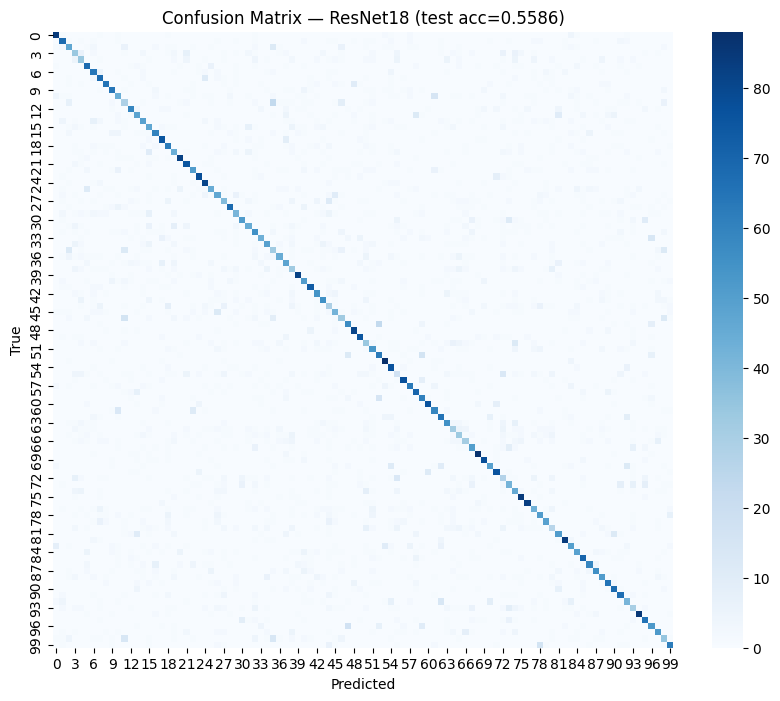


Per-class accuracy (first 20 classes):
00 apple               : 0.840
01 aquarium_fish       : 0.680
02 baby                : 0.470
03 bear                : 0.340
04 beaver              : 0.340
05 bed                 : 0.680
06 bee                 : 0.640
07 beetle              : 0.680
08 bicycle             : 0.650
09 bottle              : 0.640
10 bowl                : 0.440
11 boy                 : 0.290
12 bridge              : 0.590
13 bus                 : 0.480
14 butterfly           : 0.490
15 camel               : 0.470
16 can                 : 0.600
17 castle              : 0.750
18 caterpillar         : 0.620
19 cattle              : 0.440
Some correct predictions:


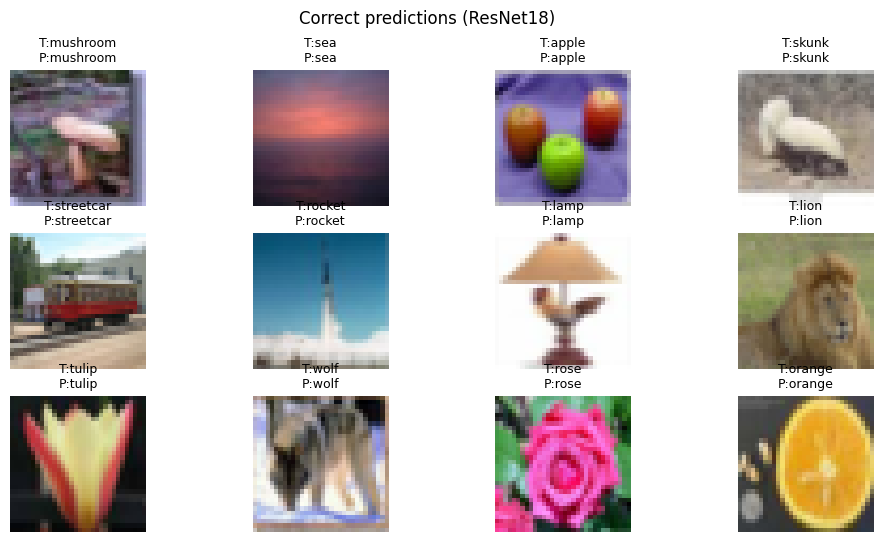

Some wrong predictions:


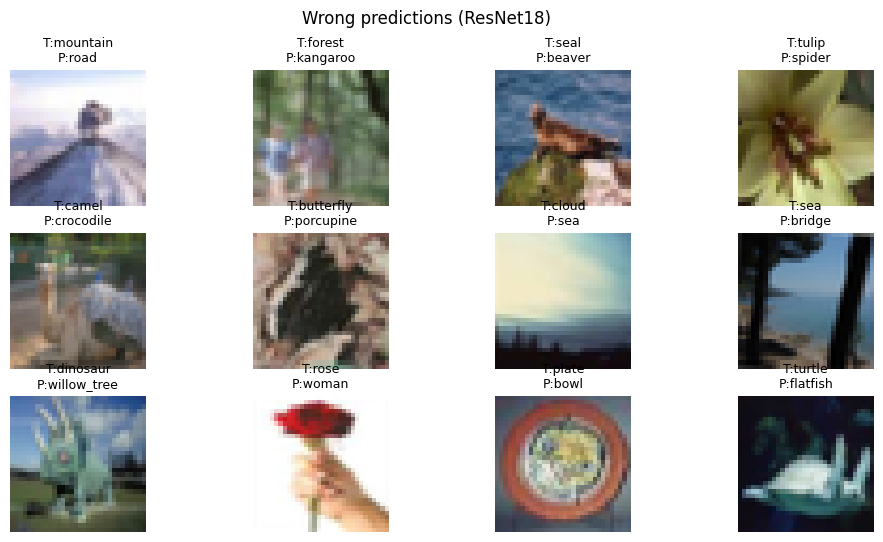

In [19]:
# Evaluate στο test set, confusion matrix, per-class accuracy, και δείγματα.

# Φόρτωση του καλύτερου checkpoint (αν υπάρχει).
if best_ckpt is not None:
    print("Loading best checkpoint:", best_ckpt)
    ckpt = torch.load(best_ckpt, map_location=device)
    backbone.load_state_dict(ckpt['model_state_dict']) # ενημέρωση μοντέλου με τα καλύτερα βάρη.
else:
    print("No best checkpoint found, using current model weights.")

# Evaluate στο test set.
test_loss, test_acc, test_time, test_preds, test_targets = evaluate(backbone, test_loader, criterion, device)
print(f"Test: loss={test_loss:.4f} | acc={test_acc:.4f} | eval_time={test_time:.2f}s")

# Confusion matrix.
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title(f"Confusion Matrix — ResNet18 (test acc={test_acc:.4f})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Per-class accuracy.
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-12)
print("\nPer-class accuracy (first 20 classes):")
for i in range(20):
    print(f"{i:02d} {label_names[i]:20s}: {per_class_acc[i]:.3f}")

# Εμφάνιση τυχαίων σωστών και λανθασμένων προβλέψεων.
def show_examples_from_preds(preds, targets, n_show=12):
    # Φορτώνουμε πρώτα raw εικόνες χωρίς normalization για εμφάνιση.
    vis_transform = T.Compose([T.ToPILImage(), T.ToTensor()])  # επιστρέφει tensor 0..1.
    vis_dataset = CIFAR100Raw(x_test, y_test, transform=vis_transform)
    # Εμφάνιση των πρώτων N εικόνων από το test set με βάση preds/targets που έχουμε.
    correct_idxs = np.where(preds == targets)[0].tolist()
    wrong_idxs   = np.where(preds != targets)[0].tolist()

    def display_idxs(idxs, title):
        plt.figure(figsize=(12,6))
        for i, idx in enumerate(idxs[:n_show]):
            img, _ = vis_dataset[idx]
            img_np = (img.permute(1,2,0).numpy() * 255.0).astype(np.uint8)
            plt.subplot(3, 4, i+1)
            plt.imshow(img_np)
            plt.title(f"T:{label_names[targets[idx]]}\nP:{label_names[preds[idx]]}", fontsize=9)
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

    print("Some correct predictions:")
    display_idxs(correct_idxs, "Correct predictions (ResNet18)")

    print("Some wrong predictions:")
    display_idxs(wrong_idxs, "Wrong predictions (ResNet18)")

# Κλήση συνάρτησης για εμφάνιση 12 σωστών και λανθασμένων προβλέψεων.
show_examples_from_preds(test_preds, test_targets, n_show=12)


# 9 Σύγκριση με k-NN (1 & 3) και Nearest Centroid.


In [34]:
# Κελί 9: Σύγκριση με 1-NN, 3-NN και Nearest Centroid
# --------------------------------------------------
# Επιλογές: χρήση raw pixels ή χρήση features από ResNet (προτείνεται features -> δίκαιη σύγκριση)
# Θα κάνουμε και τα δύο: α) raw pixels (όπως ενδιάμεση εργασία) β) features από το backbone

# --- A. Raw pixels (normalized to [0,1]) ---
print("\n--- sklearn on raw pixels (may be slow) ---")
Xtr_raw = x_train.astype(np.float32) / 255.0  # (50000,3072)
Xte_raw = x_test.astype(np.float32)  / 255.0  # (10000,3072)
Ytr = y_train
Yte = y_test

# ΠΡΟΣΟΧΗ: πλήρης εκτέλεση με 50k train / 10k test μπορεί να είναι αργή.
# Αν θέλεις, κάνε USE_SK_SUBSET=True για να τρέξει μόνο σε υποσύνολο.
USE_SK_SUBSET = True
if USE_SK_SUBSET:
    rng = np.random.RandomState(42)
    tr_idx = rng.choice(Xtr_raw.shape[0], size=20000, replace=False)
    te_idx = rng.choice(Xte_raw.shape[0],  size=5000,  replace=False)
    Xtr_skl = Xtr_raw[tr_idx]; Ytr_skl = Ytr[tr_idx]
    Xte_skl = Xte_raw[te_idx];  Yte_skl = Yte[te_idx]
else:
    Xtr_skl = Xtr_raw; Ytr_skl = Ytr
    Xte_skl = Xte_raw;  Yte_skl = Yte

# 1-NN
t0 = time.perf_counter()
knn1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn1.fit(Xtr_skl, Ytr_skl)
fit1 = time.perf_counter() - t0
t1 = time.perf_counter()
yp1 = knn1.predict(Xte_skl)
pred1 = time.perf_counter() - t1
acc1 = accuracy_score(Yte_skl, yp1)
print(f"1-NN (raw): acc={acc1:.4f} | fit={fit1:.2f}s | predict={pred1:.2f}s")

# 3-NN
t0 = time.perf_counter()
knn3 = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn3.fit(Xtr_skl, Ytr_skl)
fit3 = time.perf_counter() - t0
t1 = time.perf_counter()
yp3 = knn3.predict(Xte_skl)
pred3 = time.perf_counter() - t1
acc3 = accuracy_score(Yte_skl, yp3)
print(f"3-NN (raw): acc={acc3:.4f} | fit={fit3:.2f}s | predict={pred3:.2f}s")

# Nearest Centroid
t0 = time.perf_counter()
nc = NearestCentroid()
nc.fit(Xtr_skl, Ytr_skl)
fit_nc = time.perf_counter() - t0
t1 = time.perf_counter()
ypnc = nc.predict(Xte_skl)
pred_nc = time.perf_counter() - t1
acc_nc = accuracy_score(Yte_skl, ypnc)
print(f"Nearest Centroid (raw): acc={acc_nc:.4f} | fit={fit_nc:.2f}s | predict={pred_nc:.2f}s")

# --- B. Features from ResNet backbone (προτείνεται) ---
# Εξάγουμε features από την προεκπαιδευμένη ResNet (πριν το final fc).
# Θα δημιουργήσουμε ένα μικρό model που επιστρέφει features (global avgpooled).
print("\n--- sklearn on ResNet features (recommended) ---")

# Δημιουργία feature extractor: ResNet χωρίς final fc (επιστρέφουμε vector)
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, resnet_model):
        super().__init__()
        # Παίρνουμε όλα τα layers εκτός του final fully connected
        self.features = nn.Sequential(*list(resnet_model.children())[:-1])  # until avgpool
    def forward(self, x):
        x = self.features(x)               # output shape: (N, C, 1, 1)
        x = torch.flatten(x, 1)            # (N, C)
        return x

# Δημιουργία extractor και μεταφορά στη συσκευή
extractor = ResNetFeatureExtractor(backbone).to(device)
extractor.eval()

# Function to compute features for a DataLoader and return numpy arrays
def compute_features(model_extractor, loader, device):
    feats_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            f = model_extractor(imgs)
            feats_list.append(f.cpu().numpy())
            labels_list.append(targets.numpy())
    feats = np.concatenate(feats_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return feats, labels

# Compute features for train and test (can be slow depending on dataset size)
# Use subsets if needed
if USE_SK_SUBSET:
    # build subset dataloaders matching tr_idx / te_idx used above
    # We'll make DataLoaders with batch_size same as earlier
    sub_tr_dataset = Subset(full_train, tr_idx)  # note: full_train has augmentation; ideally disable augmentation here
    sub_te_dataset = Subset(full_test, te_idx)
    # For features extraction we should use test_transform (no augmentation)
    # So recreate datasets without augmentation for accurate features:
    feat_tr_dataset = CIFAR100Raw(x_train[tr_idx], y_train[tr_idx], transform=test_transform)
    feat_te_dataset = CIFAR100Raw(x_test[te_idx],  y_test[te_idx],  transform=test_transform)
    feat_tr_loader = DataLoader(feat_tr_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    feat_te_loader = DataLoader(feat_te_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
else:
    feat_tr_loader = DataLoader(CIFAR100Raw(x_train, y_train, transform=test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    feat_te_loader = DataLoader(CIFAR100Raw(x_test, y_test, transform=test_transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("Computing train features (ResNet)...")
Xtr_feats, Ytr_feats = compute_features(extractor, feat_tr_loader, device)
print("Computing test features (ResNet)...")
Xte_feats, Yte_feats = compute_features(extractor, feat_te_loader, device)
print("Features shapes:", Xtr_feats.shape, Xte_feats.shape)

# Fit sklearn classifiers on features
t0 = time.perf_counter()
knn1f = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn1f.fit(Xtr_feats, Ytr_feats)
fit1f = time.perf_counter() - t0
t1 = time.perf_counter()
yp1f = knn1f.predict(Xte_feats)
pred1f = time.perf_counter() - t1
acc1f = accuracy_score(Yte_feats, yp1f)
print(f"1-NN (ResNet feats): acc={acc1f:.4f} | fit={fit1f:.2f}s | predict={pred1f:.2f}s")

t0 = time.perf_counter()
knn3f = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn3f.fit(Xtr_feats, Ytr_feats)
fit3f = time.perf_counter() - t0
t1 = time.perf_counter()
yp3f = knn3f.predict(Xte_feats)
pred3f = time.perf_counter() - t1
acc3f = accuracy_score(Yte_feats, yp3f)
print(f"3-NN (ResNet feats): acc={acc3f:.4f} | fit={fit3f:.2f}s | predict={pred3f:.2f}s")

t0 = time.perf_counter()
ncf = NearestCentroid()
ncf.fit(Xtr_feats, Ytr_feats)
fit_ncf = time.perf_counter() - t0
t1 = time.perf_counter()
ypncf = ncf.predict(Xte_feats)
pred_ncf = time.perf_counter() - t1
acc_ncf = accuracy_score(Yte_feats, ypncf)
print(f"Nearest Centroid (ResNet feats): acc={acc_ncf:.4f} | fit={fit_ncf:.2f}s | predict={pred_ncf:.2f}s")



--- sklearn on raw pixels (may be slow) ---
1-NN (raw): acc=0.1400 | fit=0.02s | predict=32.72s
3-NN (raw): acc=0.1188 | fit=0.03s | predict=18.94s
Nearest Centroid (raw): acc=0.1040 | fit=1.01s | predict=0.22s

--- sklearn on ResNet features (recommended) ---
Computing train features (ResNet)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing test features (ResNet)...
Features shapes: (20000, 512) (5000, 512)
1-NN (ResNet feats): acc=0.4436 | fit=0.01s | predict=3.11s
3-NN (ResNet feats): acc=0.4362 | fit=0.01s | predict=3.83s
Nearest Centroid (ResNet feats): acc=0.5254 | fit=0.14s | predict=0.04s
